In [1]:
import pandas as pd
import numpy as np

In [2]:
water_bodies_df = pd.read_csv("DataSets/Greater Hyderabad WaterBodies DataSet.csv")  # your actual filename
print(water_bodies_df.columns)
print(water_bodies_df.shape)
print(water_bodies_df.head())

Index(['X', 'Y', 'OBJECTID', 'SNO', 'DMV_T', 'T_No', 'TANK_N', 'DMV_N',
       'DMV_C', 'DM_N', 'DM_C', 'D_N', 'D_C', 'HAB_N', 'HAB_C', 'SBDIV',
       'SBDIV_C', 'DIV', 'DIV_C', 'CIRCLE', 'CIRCLE_C', 'LAT', 'LON', 'T_TYPE',
       'TANK_P', 'TOPO_ID', 'TOPO_SC', 'SB', 'SB_C', 'MIB', 'MIB_C', 'MJB',
       'MJB_C', 'Grp', 'Sit', 'WUA_P', 'Dis_V_Km', 'Water_Spre', 'TDC_MCFT',
       'REMARKS', 'point_sno', 'A_N', 'A_C', 'N_HAB_C', 'Test', 'PHASE',
       'AYACUT', 'UID', 'Tank_N_Ori', 'Shape_Length', 'Shape_Area',
       'Tank_Name'],
      dtype='object')
(2324, 52)
           X          Y  OBJECTID    SNO DMV_T T_No TANK_N  \
0  78.056728  17.168988     11597  40787               NaN   
1  78.063885  17.168181     11598  40788               NaN   
2  78.065258  17.130530     11599  40789               NaN   
3  78.013992  17.090694     11600  40790               NaN   
4  78.030140  17.090838     11601  40791               NaN   

                 DMV_N   DMV_C          DM_N  ... A_C 

In [3]:
merged = pd.read_csv("hyderabad_water_merged_v4.csv") 

In [4]:
keep_cols = [
    "X", "Y",              # real coordinates (longitude, latitude)
    "DM_N",                 # district — for filtering to Hyderabad-area
    "DMV_N",                 # mandal/division name
    "HAB_N",                 # village/habitation
    "Water_Spre",             # water spread area — key stress-relevant metric
]

water_bodies_slim = water_bodies_df[keep_cols].copy()
print(water_bodies_slim.shape)
water_bodies_slim.head()

(2324, 6)


,X,Y,DM_N,DMV_N,HAB_N,Water_Spre
0,78.056728,17.168988,Kondurg,Regadi Chilakamarri,Regadi Chilakama,5.209149
1,78.063885,17.168181,Kondurg,Regadi Chilakamarri,Regadi Chilakama,2.357678
2,78.065258,17.130530,Kondurg,Uttaraspalle,Bhirampalle,8.665970
3,78.013992,17.090694,Chowdergudem,Thoompalle,Kondurg (East),5.573415
4,78.030140,17.090838,Kondurg,Kondurg(West),Kondurg (East),6.228099


In [5]:
water_bodies_slim.to_csv("water_bodies_slim.csv", index=False)

In [6]:
for col in ['DM_N', 'DMV_N', 'Water_Spre']:
    blank_or_na = water_bodies_slim[col].isna().sum()
    if water_bodies_slim[col].dtype == object:
        blank_or_na += (water_bodies_slim[col].astype(str).str.strip() == '').sum()
    print(col, '-> NaN or blank:', blank_or_na, '/', len(water_bodies_slim))

# also check for zeros specifically in Water_Spre, since 0 might be what you're seeing as "missing"
print("\nWater_Spre == 0:", (water_bodies_slim["Water_Spre"] == 0).sum())
print(water_bodies_slim["Water_Spre"].describe())

DM_N -> NaN or blank: 6 / 2324
DMV_N -> NaN or blank: 52 / 2324
Water_Spre -> NaN or blank: 0 / 2324

Water_Spre == 0: 194
count    2324.000000
mean       20.377459
std       165.339303
min         0.000000
25%         2.518670
50%         6.149803
75%        15.154886
max      5845.893730
Name: Water_Spre, dtype: float64


In [7]:
zero_spread = water_bodies_slim[water_bodies_slim["Water_Spre"] == 0]
print(zero_spread[["DM_N"]].value_counts().head(10))

DM_N          
Farooqnagar       21
Keshampeta        17
Chowdergudem      16
Talakondapalle    12
Madgul            12
Kadthal           11
Kondurg            9
Moinabad           8
Abdullapurmet      7
Gandipet           6
Name: count, dtype: int64


In [8]:
sections = set(merged["section"].astype(str).str.upper().str.strip())
mandals = set(water_bodies_slim["DM_N"].astype(str).str.upper().str.strip())

print("Direct name matches:", len(sections & mandals))
print(sections & mandals)

print("\nIn sections not in mandals:", len(sections - mandals))
print("In mandals not in sections:", len(mandals - sections))

Direct name matches: 12
{'BALAPUR', 'BALANAGAR', 'AMBERPET', 'KUKATPALLY', 'MUSHEERABAD', 'SHAIKPET', 'BAHADURPURA', 'ALWAL', 'SAROORNAGAR', 'SHAMSHABAD', 'UPPAL', 'BANDLAGUDA'}

In sections not in mandals: 175
In mandals not in sections: 44


In [11]:
main_df = pd.read_csv("hyderabad_water_merged_v4.csv")   # use whichever version has coordinates + groundwater

sections_unique = main_df[["section", "latitude", "longitude"]].drop_duplicates(subset="section").reset_index(drop=True)
print(sections_unique.shape)
print(sections_unique.head())

(187, 3)
       section   latitude  longitude
0  ADARSHNAGAR  17.404547  78.473584
1      ADIKMET  17.409550  78.513094
2  AHMED NAGAR  17.404066  78.444229
3      ALIABAD  17.345630  78.472680
4     ALKAPURI  17.366234  78.554978


In [12]:
%whos

Variable               Type         Data/Info
---------------------------------------------
blank_or_na            int64        0
col                    str          Water_Spre
dataframe_columns      function     <function dataframe_colum<...>ns at 0x0000020824866980>
dataframe_hash         function     <function dataframe_hash at 0x0000020824866520>
dtypes_str             function     <function dtypes_str at 0x0000020824865940>
get_dataframes         function     <function get_dataframes at 0x0000020824866660>
getpass                module       <module 'getpass' from 'C<...>conda3\\Lib\\getpass.py'>
hashlib                module       <module 'hashlib' from 'C<...>conda3\\Lib\\hashlib.py'>
import_pandas_safely   function     <function import_pandas_s<...>ly at 0x0000020827C107C0>
is_data_frame          function     <function is_data_frame at 0x0000020827C10040>
json                   module       <module 'json' from 'C:\\<...>\Lib\\json\\__init__.py'>
keep_cols              list     

In [13]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth's radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

In [17]:
radius_km = 3

water_body_features = []

for _, row in sections_unique.iterrows():
    distances = haversine(row["latitude"], row["longitude"], water_bodies_slim["Y"], water_bodies_slim["X"])
    nearby = water_bodies_slim[distances <= radius_km]
    
    water_body_features.append({
        "section": row["section"],
        "nearby_water_body_count": len(nearby),
        "nearby_water_spread_total": nearby["Water_Spre"].sum()
    })

water_body_features_df = pd.DataFrame(water_body_features)
print(water_body_features_df.head(10))
print(water_body_features_df.describe())

       section  nearby_water_body_count  nearby_water_spread_total
0  ADARSHNAGAR                        4                1356.972184
1      ADIKMET                        8                  85.540442
2  AHMED NAGAR                        9                  57.143820
3      ALIABAD                       10                  63.167633
4     ALKAPURI                       13                 146.578046
5    ALLABANDA                        5                  13.421760
6        ALWAL                       19                 105.743561
7   ASIF NAGAR                        6                  15.651132
8    ASMANGARH                        5                 186.407786
9      ATTAPUR                       12                 511.661137
       nearby_water_body_count  nearby_water_spread_total
count               187.000000                 187.000000
mean                 12.684492                 268.916656
std                   7.092471                 321.288517
min                   0.000000 

In [18]:
zero_wb = water_body_features_df[water_body_features_df["nearby_water_body_count"] == 0]
print(len(zero_wb))
print(zero_wb["section"].tolist())

2
['PATANCHERU', 'PATHANCHERU']


In [19]:
print(main_df[main_df["section"].isin(["PATANCHERU", "PATHANCHERU"])][["section", "latitude", "longitude"]].drop_duplicates())

         section   latitude  longitude
442   PATANCHERU  17.528609  78.267425
443  PATHANCHERU  17.533307  78.268998


In [20]:
row = sections_unique[sections_unique["section"].isin(["PATANCHERU", "PATHANCHERU"])].iloc[0]
distances = haversine(row["latitude"], row["longitude"], water_bodies_slim["Y"], water_bodies_slim["X"])
print("Nearest water body distance:", distances.min(), "km")

Nearest water body distance: 5.8336188899639945 km


In [23]:
# check the nearest distance (not just count-within-radius) for every section
nearest_distances = []
for _, row in sections_unique.iterrows():
    distances = haversine(row["latitude"], row["longitude"], water_bodies_slim["Y"], water_bodies_slim["X"])
    nearest_distances.append({"section": row["section"], "nearest_wb_distance": distances.min()})

nearest_wb_df = pd.DataFrame(nearest_distances)
print(nearest_wb_df["nearest_wb_distance"].describe())
print(nearest_wb_df[nearest_wb_df["nearest_wb_distance"] > 3].sort_values("nearest_wb_distance", ascending=False))

count    187.000000
mean       0.933543
std        0.766313
min        0.051478
25%        0.471191
50%        0.760664
75%        1.163508
max        5.951965
Name: nearest_wb_distance, dtype: float64
         section  nearest_wb_distance
175  PATHANCHERU             5.951965
174   PATANCHERU             5.833619


In [24]:
main_df["section"] = main_df["section"].replace("PATANCHERU", "PATHANCHERU")
sections_unique["section"] = sections_unique["section"].replace("PATANCHERU", "PATHANCHERU")
sections_unique = sections_unique.drop_duplicates(subset="section")

print(sections_unique["section"].nunique())  # should now be 186, not 187

186


In [25]:
radius_km = 3
water_body_features = []

for _, row in sections_unique.iterrows():
    distances = haversine(row["latitude"], row["longitude"], water_bodies_slim["Y"], water_bodies_slim["X"])
    nearby = water_bodies_slim[distances <= radius_km]
    water_body_features.append({
        "section": row["section"],
        "nearby_water_body_count": len(nearby),
        "nearby_water_spread_total": nearby["Water_Spre"].sum()
    })

water_body_features_df = pd.DataFrame(water_body_features)
print("Sections with 0 nearby:", (water_body_features_df["nearby_water_body_count"] == 0).sum())

Sections with 0 nearby: 1


In [28]:
final_merged_v2 = main_df.merge(water_body_features_df, on="section", how="left")

print(final_merged_v2.shape)
print("Missing water body data:", final_merged_v2["nearby_water_body_count"].isna().sum())

final_merged_v2.to_csv("hyderabad_water_merged_v5.csv", index=False)

(4188, 18)
Missing water body data: 0


In [29]:
final_check = pd.read_csv("hyderabad_water_merged_v5.csv")
print(final_check.shape)
print(final_check.columns.tolist())
print(final_check.isna().sum())
print(final_check.describe())

(4188, 18)
['year', 'month', 'section', 'division', 'noofbookings', 'delivered', 'applied', 'approved', 'collection', 'demand', 'noofcans', 'latitude', 'longitude', 'gwl_mean', 'gwl_min', 'gwl_max', 'nearby_water_body_count', 'nearby_water_spread_total']
year                           0
month                          0
section                        0
division                       0
noofbookings                   0
delivered                      0
applied                      103
approved                     103
collection                    12
demand                        12
noofcans                      12
latitude                       0
longitude                      0
gwl_mean                       0
gwl_min                        0
gwl_max                        0
nearby_water_body_count        0
nearby_water_spread_total      0
dtype: int64
              year        month     division  noofbookings     delivered  \
count  4188.000000  4188.000000  4188.000000   4188.000000   4

In [30]:
extreme_demand = final_check[final_check["demand"] < 0]
print(extreme_demand[["section", "year", "month", "demand"]])

# also check for absurdly large positive outliers
print(final_check.nlargest(5, "demand")[["section", "year", "month", "demand"]])


                  section  year  month        demand
219     GUNDLAPOCHAMPALLY  2022      2 -1.478245e+07
222             HAKEEMPET  2022      2 -3.659238e+07
230              JALPALLY  2022      2 -8.010345e+04
242                  KPHB  2022      2 -4.920665e+09
718   FATHER BALAIAHNAGAR  2022      5 -6.336640e+06
1428        MACHABOLLARAM  2022      9 -3.801188e+05
1551           FATHENAGAR  2022     10 -3.281000e+02
1711          DHAMMAIGUDA  2022     11 -2.991484e+07
1777              NAGARAM  2022     11 -5.419126e+06
2049    GUNDLAPOCHAMPALLY  2023      2 -1.478245e+07
2052            HAKEEMPET  2023      2 -3.659238e+07
2060             JALPALLY  2023      2 -8.010345e+04
2074                 KPHB  2023      2 -4.920665e+09
2550  FATHER BALAIAHNAGAR  2023      5 -6.336640e+06
3074    GUNDLAPOCHAMPALLY  2023      8 -2.827705e+05
3272        MACHABOLLARAM  2023      9 -3.801188e+05
3398           FATHENAGAR  2023     10 -3.281000e+02
3543           BEERAMGUDA  2023     11 -1.0361

In [31]:
positive_gwl = final_check[final_check["gwl_max"] > 5]
print(positive_gwl[["section", "gwl_mean", "gwl_min", "gwl_max"]].drop_duplicates())

                  section   gwl_mean  gwl_min  gwl_max
0             ADARSHNAGAR  -4.225103   -6.030   25.278
4                ALKAPURI -15.115934  -24.000   38.681
8               ASMANGARH  -9.772094  -15.772    8.350
13             BACHUPALLY -77.335640  -83.420   20.074
21             BEERAMGUDA -10.108600  -48.466   12.475
31           CHANCHALGUDA  -9.772094  -15.772    8.350
40            DHAMMAIGUDA -19.770034  -59.541   14.483
43              DOMALGUDA  -4.225103   -6.030   25.278
46    FATHER BALAIAHNAGAR -16.764837  -24.574   36.118
50            GANDHINAGAR  -4.225103   -6.030   25.278
63              HYDERGUDA  -4.225103   -6.030   25.278
77              KOTHAPETA -15.115934  -24.000   38.681
78                   KPHB -46.347037  -48.923   38.884
79             KUKATPALLY -46.347037  -48.923   38.884
81                LALAPET  -2.264306   -6.600   31.337
85             MADANNAPET  -9.772094  -15.772    8.350
88               MALAKPET  -9.772094  -15.772    8.350
91        

In [32]:
# flag clearly nonsensical values — demand shouldn't be negative or absurdly large
bad_demand = final_check[(final_check["demand"] < 0) | (final_check["demand"] > 1e8)]
print(len(bad_demand), "rows affected")

final_check.loc[(final_check["demand"] < 0) | (final_check["demand"] > 1e8), "demand"] = None
print("New missing count:", final_check["demand"].isna().sum())

29 rows affected
New missing count: 41


In [33]:
final_check.describe()

,year,month,division,noofbookings,delivered,applied,approved,collection,demand,noofcans,latitude,longitude,gwl_mean,gwl_min,gwl_max,nearby_water_body_count,nearby_water_spread_total
count,4188.000000,4188.000000,4188.000000,4188.000000,4188.000000,4085.000000,4085.000000,4.176000e+03,4.147000e+03,4176.000000,4188.000000,4188.000000,4188.000000,4188.000000,4188.000000,4188.000000,4188.000000
mean,2022.644222,5.862464,11.747135,307.204155,307.064231,26.362056,12.920685,3.615616e+06,7.419932e+06,7612.542864,17.412508,78.478919,-10.640501,-21.309923,3.652677,12.852436,269.843196
std,0.626211,3.422581,8.850336,806.835217,806.640010,59.267409,37.065327,8.421275e+06,9.526440e+06,3066.257062,0.064814,0.069038,10.701345,19.519422,11.302559,6.954539,319.937694
min,2022.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000e+00,4.351340e+04,26.000000,17.176690,78.267425,-77.335640,-104.503000,-11.334000,0.000000,0.000000
25%,2022.000000,3.000000,5.000000,15.000000,15.000000,5.000000,1.000000,5.300623e+05,2.402173e+06,5785.000000,17.365895,78.430728,-12.474141,-24.000000,-1.252000,7.000000,102.171230
50%,2023.000000,6.000000,10.000000,76.000000,76.000000,11.000000,4.000000,1.343712e+06,4.415553e+06,7015.000000,17.404547,78.482533,-6.855199,-15.772000,1.000000,13.000000,199.140009
75%,2023.000000,9.000000,15.000000,224.000000,224.000000,26.000000,11.000000,3.469512e+06,8.729819e+06,8790.000000,17.459069,78.536458,-4.981352,-8.085000,1.000000,17.000000,281.905782
max,2024.000000,12.000000,34.000000,10037.000000,10037.000000,905.000000,573.000000,1.596594e+08,9.616306e+07,24375.000000,17.576965,78.638451,-0.627978,-1.670000,38.884000,29.000000,1402.275651


In [34]:
final_check.to_csv("hyderabad_water_merged_v6.csv", index=False)

array([[<Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'month'}>,
        <Axes: title={'center': 'division'}>,
        <Axes: title={'center': 'noofbookings'}>],
       [<Axes: title={'center': 'delivered'}>,
        <Axes: title={'center': 'applied'}>,
        <Axes: title={'center': 'approved'}>,
        <Axes: title={'center': 'collection'}>],
       [<Axes: title={'center': 'demand'}>,
        <Axes: title={'center': 'noofcans'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'longitude'}>],
       [<Axes: title={'center': 'gwl_mean'}>,
        <Axes: title={'center': 'gwl_min'}>,
        <Axes: title={'center': 'gwl_max'}>,
        <Axes: title={'center': 'nearby_water_body_count'}>],
       [<Axes: title={'center': 'nearby_water_spread_total'}>, <Axes: >,
        <Axes: >, <Axes: >]], dtype=object)

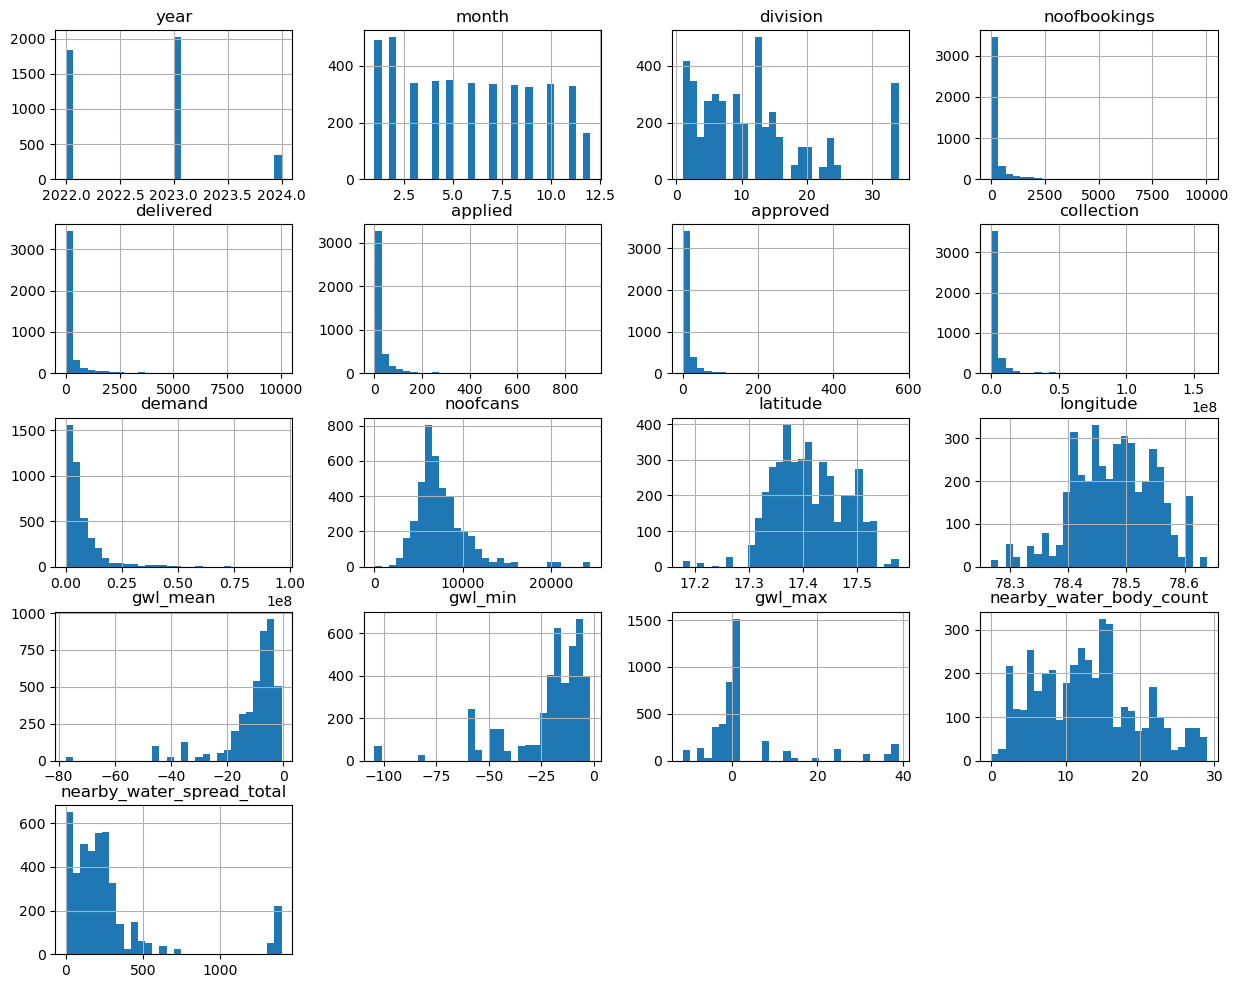

In [37]:
final_check.hist(figsize=(15, 12), bins=30)

In [38]:
final_check["division"].value_counts().sort_index().tail(10)

division
16    148
18     50
19    114
20    113
22     44
23     90
24     54
25     49
33    141
34    200
Name: count, dtype: int64

In [39]:
final_check[final_check["nearby_water_spread_total"] > 600]["section"].unique()

array(['ADARSHNAGAR', 'BOIGUDA', 'CHINTAL BASTHI', 'DOMALGUDA',
       'GANDHINAGAR', 'HYDERGUDA', 'JAWAHARNAGAR', 'JEEDIMETLA',
       'MAILERDEV PALLY', 'MUSHEERABAD', 'NALLAGUTTA', 'PRAKASHNAGAR',
       'SOMAJIGUDA', 'THUKKUGUDA', 'CONTROL ROOM'], dtype=object)

In [40]:
print(final_check[final_check["section"] == "CONTROL ROOM"])

      year  month       section  division  noofbookings  delivered  applied  \
3223  2023      9  CONTROL ROOM        11             1          1      NaN   

      approved   collection       demand  noofcans   latitude  longitude  \
3223       NaN  78009276.52  70024768.41      26.0  17.401112  78.472827   

      gwl_mean  gwl_min  gwl_max  nearby_water_body_count  \
3223 -4.225103    -6.03   25.278                        5   

      nearby_water_spread_total  
3223                1357.589721  


In [43]:
final_check = final_check[final_check["section"] != "CONTROL ROOM"]

print("Sections remaining:", final_check["section"].nunique())
print("Rows remaining:", len(final_check))

final_check.to_csv("hyderabad_water_merged_v5.csv", index=False)

Sections remaining: 185
Rows remaining: 4187


In [44]:
check = pd.read_csv("hyderabad_water_merged_v5.csv")
print(check.shape)
print(check["section"].nunique())
print((check["section"] == "CONTROL ROOM").sum())  # should be 0

(4187, 18)
185
0
